<a href="https://colab.research.google.com/github/41monster/AI_Courses/blob/main/2026_Spring_NuclearAI/PINN_CodePractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 시드 고정 (재현성 확보)
torch.manual_seed(1234)
np.random.seed(1234)

In [2]:
# -----------------------------------------------------------------------------
# 1. 문제 정의 (슬라이드 22 바탕)
# -----------------------------------------------------------------------------
# 다룰 방정식: u_t - kappa * u_xx = f(t,x)
# 도메인: (t, x) in [0, T] x [0, 1]
kappa = 0.01
T = 1.0

# 실습을 위해 정확해(Exact Solution)를 먼저 가정합니다: u(t,x) = exp(-t) * sin(pi * x)
# 이 해를 방정식에 대입하여 f(t,x), 초기조건 u_0(x), 경계조건 g(t,x)를 유도합니다.
def exact_solution(t, x):
    return torch.exp(-t) * torch.sin(np.pi * x)

def f_tx(t, x):
    # u_t = -exp(-t)*sin(pi*x)
    # u_xx = -pi^2 * exp(-t)*sin(pi*x)
    # f(t,x) = u_t - kappa * u_xx
    return torch.exp(-t) * torch.sin(np.pi * x) * (-1.0 + kappa * (np.pi ** 2))

def u_0(x):
    # 초기 조건 (t=0)
    return torch.sin(np.pi * x)

def g(t, x):
    # 경계 조건 (x=0 or x=1) -> sin(0) = sin(pi) = 0
    return torch.zeros_like(x)


In [3]:
# -----------------------------------------------------------------------------
# 2. 신경망 구조 정의 (PINN)
# -----------------------------------------------------------------------------
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # 입력: (t, x) -> 출력: u
        # PINN에서는 보통 무한 번 미분이 가능하고 부드러운 Tanh 활성화 함수를 주로 사용합니다.
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, t, x):
        tx = torch.cat([t, x], dim=1)
        return self.net(tx)

model = PINN()

In [4]:
# -----------------------------------------------------------------------------
# 3. Collocation Points 생성 (슬라이드 25, 26 - Monte-Carlo Integration)
# -----------------------------------------------------------------------------
N_pde = 2000  # PDE 내부 샘플링 포인트 수
N_ic = 100    # 초기 조건 샘플링 포인트 수
N_bc = 100    # 경계 조건 샘플링 포인트 수

# (1) PDE 도메인 내부 포인트: (t_i, x_i) ~ U([0, T] x [0, 1])
t_pde = torch.rand(N_pde, 1) * T
x_pde = torch.rand(N_pde, 1)
t_pde.requires_grad_(True) # 미분 계산을 위해 추적 활성화
x_pde.requires_grad_(True)

# (2) 초기 조건 포인트: t=0, x_k ~ U([0, 1])
t_ic = torch.zeros(N_ic, 1)
x_ic = torch.rand(N_ic, 1)

# (3) 경계 조건 포인트: t_j ~ U([0, T]), x=0 또는 x=1
t_bc = torch.rand(N_bc, 1) * T
x_bc = torch.randint(0, 2, (N_bc, 1)).float() # 0 또는 1

In [5]:
# -----------------------------------------------------------------------------
# 4. 손실 함수(Loss Function) 및 옵티마이저 정의
# -----------------------------------------------------------------------------
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def compute_loss():
    # --- R1: PDE Loss (슬라이드 23) ---
    u_pred = model(t_pde, x_pde)

    # Autograd를 사용한 자동 미분 (Gradient 계산)
    u_t = torch.autograd.grad(u_pred, t_pde, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_x = torch.autograd.grad(u_pred, x_pde, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_pde, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t - kappa * u_xx - f_tx(t_pde, x_pde)
    loss_pde = torch.mean(residual ** 2)

    # --- R2: Boundary Condition Loss (슬라이드 23) ---
    u_bc_pred = model(t_bc, x_bc)
    loss_bc = torch.mean((u_bc_pred - g(t_bc, x_bc)) ** 2)

    # --- R3: Initial Condition Loss (슬라이드 23) ---
    u_ic_pred = model(t_ic, x_ic)
    loss_ic = torch.mean((u_ic_pred - u_0(x_ic)) ** 2)

    # 전체 Loss (슬라이드 24)
    loss = loss_pde + loss_bc + loss_ic
    return loss, loss_pde, loss_bc, loss_ic

In [11]:
# -----------------------------------------------------------------------------
# 5. 모델 학습
# -----------------------------------------------------------------------------
epochs = 500
history = {'total': [], 'pde': [], 'bc': [], 'ic': []}

for epoch in range(epochs):
    optimizer.zero_grad()
    loss, loss_pde, loss_bc, loss_ic = compute_loss()
    loss.backward()
    optimizer.step()

    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['bc'].append(loss_bc.item())
    history['ic'].append(loss_ic.item())

    if epoch % 50 == 0:
        print(f'Epoch {epoch:4d} | Total Loss: {loss.item():.6f} '
              f'| PDE: {loss_pde.item():.6f} | BC: {loss_bc.item():.6f} | IC: {loss_ic.item():.6f}')


Epoch    0 | Total Loss: 0.000204 | PDE: 0.000165 | BC: 0.000024 | IC: 0.000015
Epoch   50 | Total Loss: 0.000190 | PDE: 0.000153 | BC: 0.000023 | IC: 0.000014
Epoch  100 | Total Loss: 0.000604 | PDE: 0.000147 | BC: 0.000223 | IC: 0.000235
Epoch  150 | Total Loss: 0.000173 | PDE: 0.000133 | BC: 0.000025 | IC: 0.000015
Epoch  200 | Total Loss: 0.000159 | PDE: 0.000126 | BC: 0.000021 | IC: 0.000012
Epoch  250 | Total Loss: 0.000151 | PDE: 0.000119 | BC: 0.000021 | IC: 0.000011
Epoch  300 | Total Loss: 0.000143 | PDE: 0.000112 | BC: 0.000020 | IC: 0.000011
Epoch  350 | Total Loss: 0.000138 | PDE: 0.000106 | BC: 0.000021 | IC: 0.000011
Epoch  400 | Total Loss: 0.000148 | PDE: 0.000101 | BC: 0.000027 | IC: 0.000019
Epoch  450 | Total Loss: 0.000126 | PDE: 0.000097 | BC: 0.000019 | IC: 0.000010


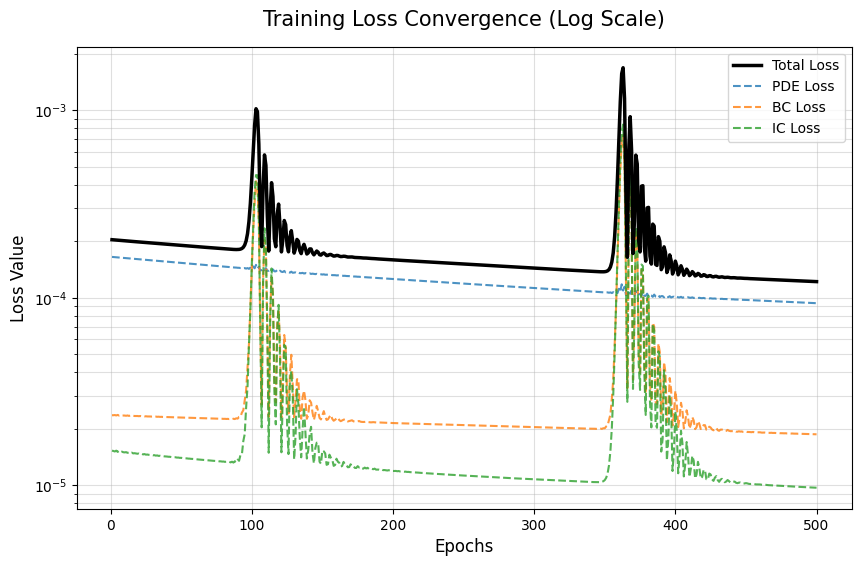

In [12]:
# -----------------------------------------------------------------------------
# 6. 결과 시각화
# -----------------------------------------------------------------------------
def plot_loss_history(history):
    plt.figure(figsize=(10, 6), dpi=100)

    # 각 Loss 성분 그래프 (로그 스케일)
    epochs = range(1, len(history['total']) + 1)

    plt.semilogy(epochs, history['total'], label='Total Loss', color='black', lw=2.5, zorder=10)
    plt.semilogy(epochs, history['pde'], label='PDE Loss', alpha=0.8, ls='--')
    plt.semilogy(epochs, history['bc'], label='BC Loss', alpha=0.8, ls='--')
    plt.semilogy(epochs, history['ic'], label='IC Loss', alpha=0.8, ls='--')

    plt.title('Training Loss Convergence (Log Scale)', fontsize=15, pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)

    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.legend(loc='upper right', fontsize=10, frameon=True)

    # 그래프 저장 (필요 시)
    # plt.savefig('loss_convergence.png', bbox_inches='tight')
    plt.show()

# 함수 실행
plot_loss_history(history)

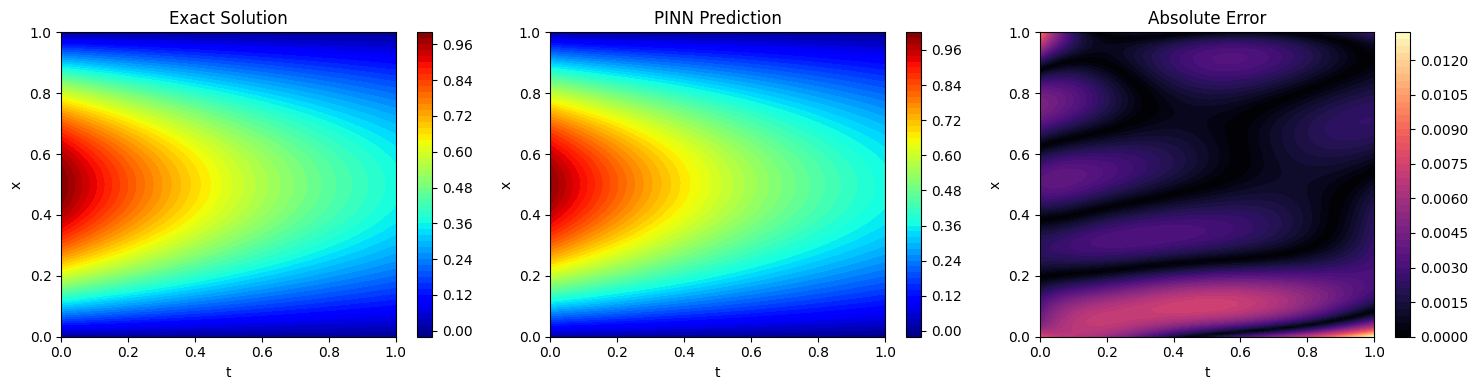

In [13]:
# -----------------------------------------------------------------------------
# 6. 결과 시각화
# -----------------------------------------------------------------------------
model.eval()
# 시각화를 위한 그리드 생성
t_test = np.linspace(0, T, 100)
x_test = np.linspace(0, 1, 100)
T_grid, X_grid = np.meshgrid(t_test, x_test)

T_tensor = torch.tensor(T_grid.flatten()[:, None], dtype=torch.float32)
X_tensor = torch.tensor(X_grid.flatten()[:, None], dtype=torch.float32)

# 예측 수행
with torch.no_grad():
    U_pred_tensor = model(T_tensor, X_tensor)
U_pred = U_pred_tensor.numpy().reshape(100, 100)
U_exact = exact_solution(T_tensor, X_tensor).numpy().reshape(100, 100)

# 플롯 그리기
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

c1 = axes[0].contourf(T_grid, X_grid, U_exact, 50, cmap='jet')
axes[0].set_title('Exact Solution')
axes[0].set_xlabel('t')
axes[0].set_ylabel('x')
fig.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(T_grid, X_grid, U_pred, 50, cmap='jet')
axes[1].set_title('PINN Prediction')
axes[1].set_xlabel('t')
axes[1].set_ylabel('x')
fig.colorbar(c2, ax=axes[1])

c3 = axes[2].contourf(T_grid, X_grid, np.abs(U_exact - U_pred), 50, cmap='magma')
axes[2].set_title('Absolute Error')
axes[2].set_xlabel('t')
axes[2].set_ylabel('x')
fig.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.show()